Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [2]:
# Specify file paths
data_file = "20260506-111818-cytation3-pure-timecourse-gfp-Ctosol-lifetime-test-biotek-cdk.txt"
platemap_file = "20260506-platemap-Cytosol-Lifetime.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Date,Experiment Name,Name,...,tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),PEG Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B2,49,B,2,GFP-F-G35,2026-05-06 11:21:00,20260506,Cytosol-Lifetime-Test,No Incubation,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10
1,0 days 00:05:00,B2,134,B,2,GFP-F-G35,2026-05-06 11:26:00,20260506,Cytosol-Lifetime-Test,No Incubation,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10
2,0 days 00:10:00,B2,1410,B,2,GFP-F-G35,2026-05-06 11:31:00,20260506,Cytosol-Lifetime-Test,No Incubation,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10
3,0 days 00:15:00,B2,4789,B,2,GFP-F-G35,2026-05-06 11:36:00,20260506,Cytosol-Lifetime-Test,No Incubation,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10
4,0 days 00:20:00,B2,9338,B,2,GFP-F-G35,2026-05-06 11:41:00,20260506,Cytosol-Lifetime-Test,No Incubation,...,1.00,0.50,NaN,NaN,NaN,NaN,NaN,NaN,2.50,10


## Plot Raw Curves

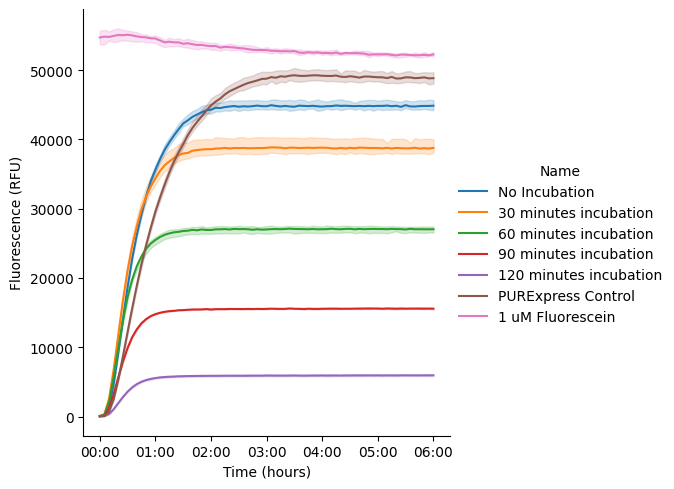

In [3]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics")

## Normalize Data

In [4]:
data = pr.normalize_data_to_controls(data, ctrl_name = '1 uM Fluorescein')

Data Normalized to 1 uM Fluorescein in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

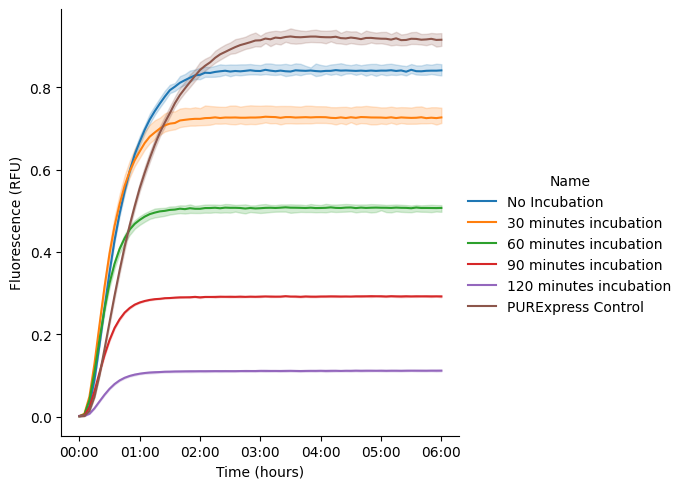

In [5]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics-normalized")

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [6]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

PROVIDING AVERAGED KINETICS


Velocity                       \
                                            Time data_normalized  Max   
Name                                                                    
120 minutes incubation 0 days 00:25:48.525610892            0.06 0.18   
30 minutes incubation  0 days 00:27:51.634244534            0.37 1.00   
60 minutes incubation  0 days 00:24:36.713653157            0.26 0.88   
90 minutes incubation  0 days 00:24:44.426871025            0.15 0.52   
No Incubation          0 days 00:33:51.010616830            0.43 0.92   

                                             Lag                  \
                                            Time data_normalized   
Name                                                               
120 minutes incubation 0 days 00:07:41.620875856            0.01   
30 minutes incubation  0 days 00:05:45.921571645            0.05   
60 minutes incubation  0 days 00:07:08.792272333            0.04   
90 minutes incubation  0 days 00:07:55.048739297            0.03   
No Incubation          0 days 00:05:51.140691060            0.04   

                                    Steady State                  \
                                            Time data_normalized   
Name                                                               
120 minutes incubation 0 days 00:52:28.687944310            0.11   
30 minutes incubation  0 days 01:00:23.374278854            0.70   
60 minutes incubation  0 days 00:50:19.483932837            0.49   
90 minutes incubation  0 days 00:49:30.453028386            0.28   
No Incubation          0 days 01:15:04.147860781            0.81   

                                                                      Fit  \
                                                                   params   
Name                                                                        
120 minutes incubation  [0.11119370277562463, 6.63055383785665, 0.4301...   
30 minutes incubation   [0.7387860430953479, 5.431977204119018, 0.4643...   
60 minutes incubation   [0.5119478530710924, 6.870766567540297, 0.4101...   
90 minutes incubation   [0.2921190942397909, 7.133341638044996, 0.4123...   
No Incubation           [0.8576498709132986, 4.286061086611621, 0.5641...   

                                   
                        R^2 drift  
Name                               
120 minutes incubation 1.00  0.00  
30 minutes incubation  1.00  0.01  
60 minutes incubation  1.00  0.00  
90 minutes incubation  1.00  0.00  
No Incubation          0.99  0.01

## Visualize Fits on Individual Wells

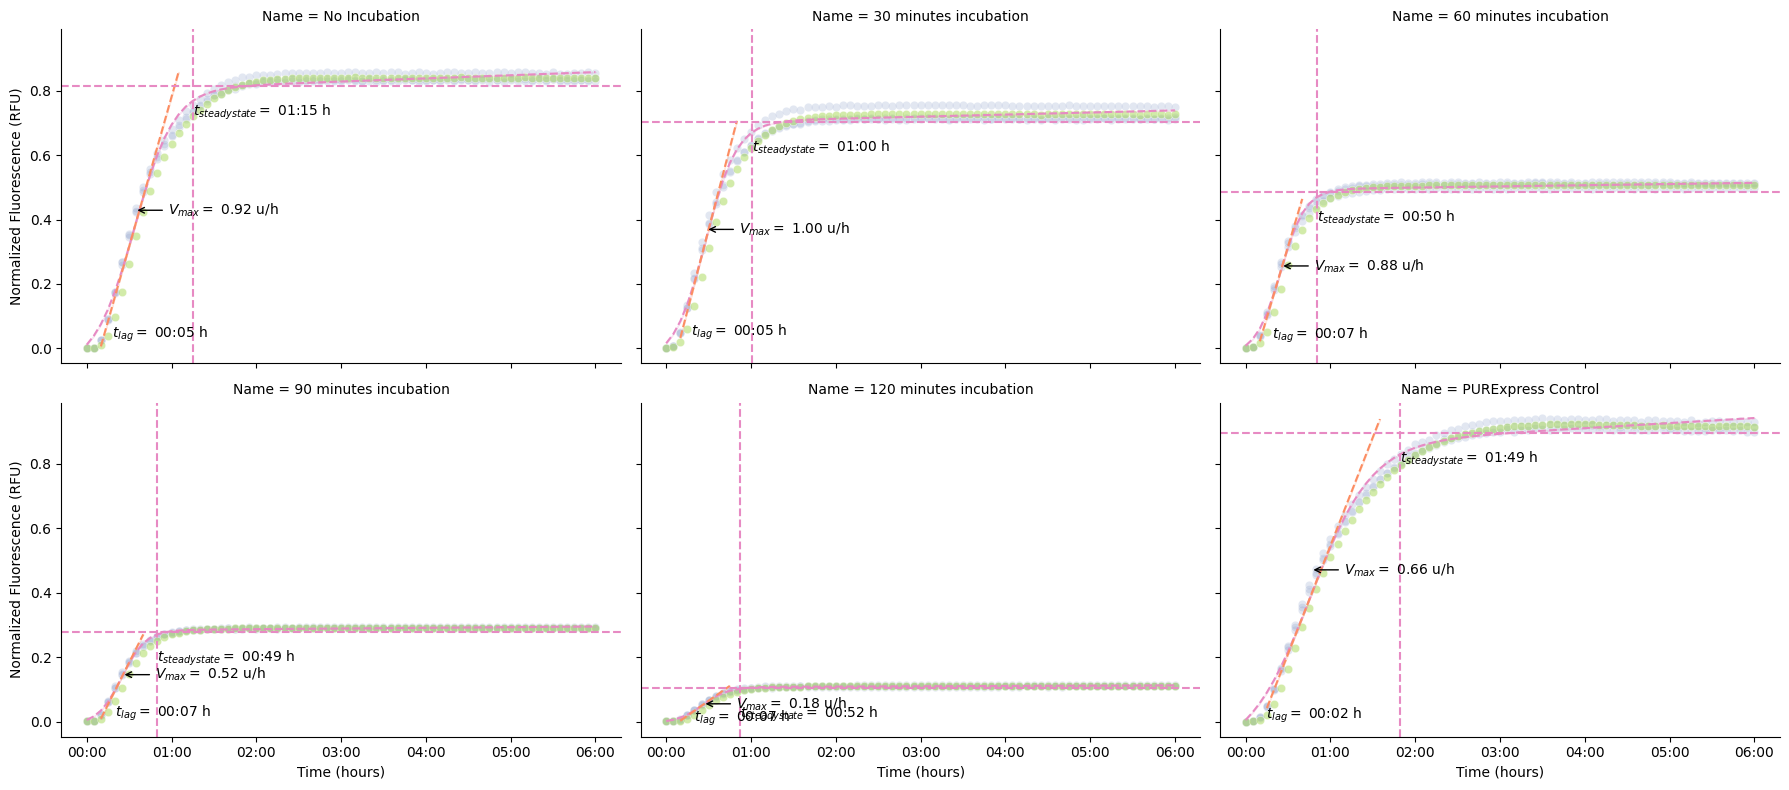

In [7]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

## Summary Plots

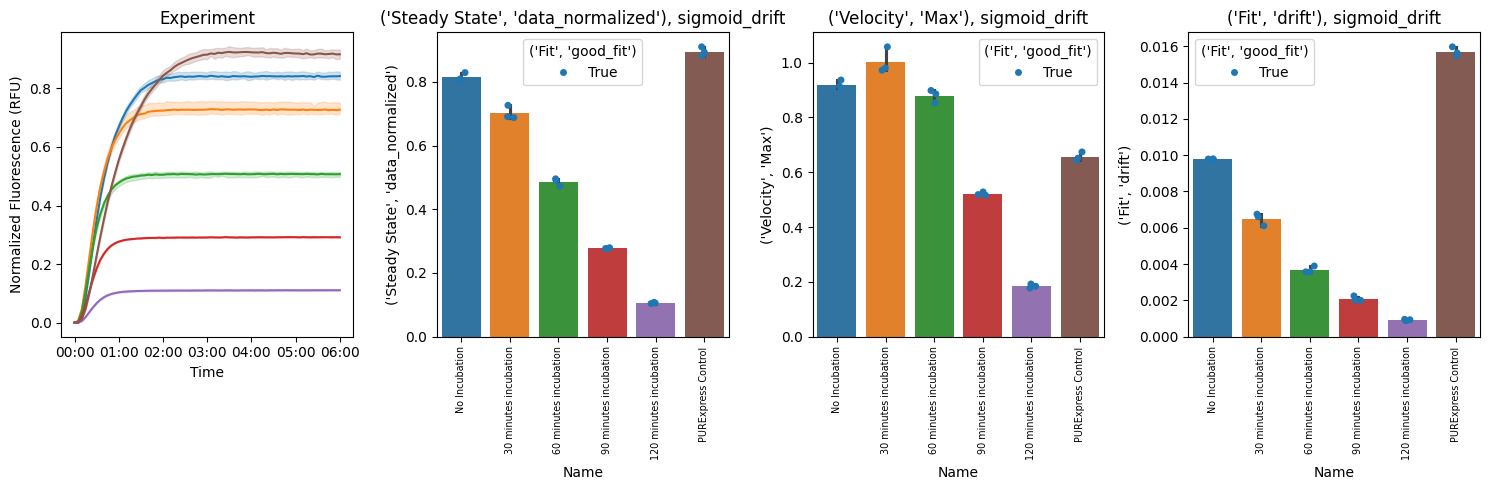

In [20]:
pr.plot_summary(data)

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants